In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
# بارگذاری داده‌ها
data = pd.read_csv('/content/Churn_Modelling.csv')


In [ ]:


# حذف ستون‌های غیرضروری مثل شناسه مشتری و نام بانک
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# جدا کردن ویژگی‌ها و هدف
X = data.drop('Exited', axis=1)
y = data['Exited']

# تعیین ویژگی‌های عددی و دسته‌ای
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']

# ساخت پیش‌پردازشور برای ویژگی‌های عددی و دسته‌ای
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))  # drop='first' برای جلوگیری از multicollinearity
])

# ترکیب پیش‌پردازش
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# تقسیم داده‌ها
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## MLP

In [ ]:

# اعمال پیش‌پردازش
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# ساخت مدل مطابق مقاله (MLP با سه لایه مخفی و ReLU + خروجی Sigmoid)
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),  # لایه اول مخفی
    layers.Dense(64, activation='relu'),   # لایه دوم مخفی
    layers.Dense(32, activation='relu'),   # لایه سوم مخفی
    layers.Dense(1, activation='sigmoid')  # لایه خروجی
])

# کامپایل مدل
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# آموزش مدل
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

# ارزیابی مدل
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')

# پیش‌بینی
predictions = model.predict(X_test)
predictions = (predictions > 0.5).astype(int)
print(f"Predictions:\n{predictions.ravel()}")


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7807 - loss: 0.4965 - val_accuracy: 0.8269 - val_loss: 0.3898
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8255 - loss: 0.3922 - val_accuracy: 0.8331 - val_loss: 0.3716
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8516 - loss: 0.3552 - val_accuracy: 0.8406 - val_loss: 0.3710
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8493 - loss: 0.3576 - val_accuracy: 0.8400 - val_loss: 0.3654
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8455 - loss: 0.3573 - val_accuracy: 0.8394 - val_loss: 0.3643
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8500 - loss: 0.3468 - val_accuracy: 0.8450 - val_loss: 0.3694
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8615 - loss: 0.3355 - val_accuracy: 0.8406 - val_loss: 0.3705
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8576 - loss: 0.3364 - val_accuracy: 0.

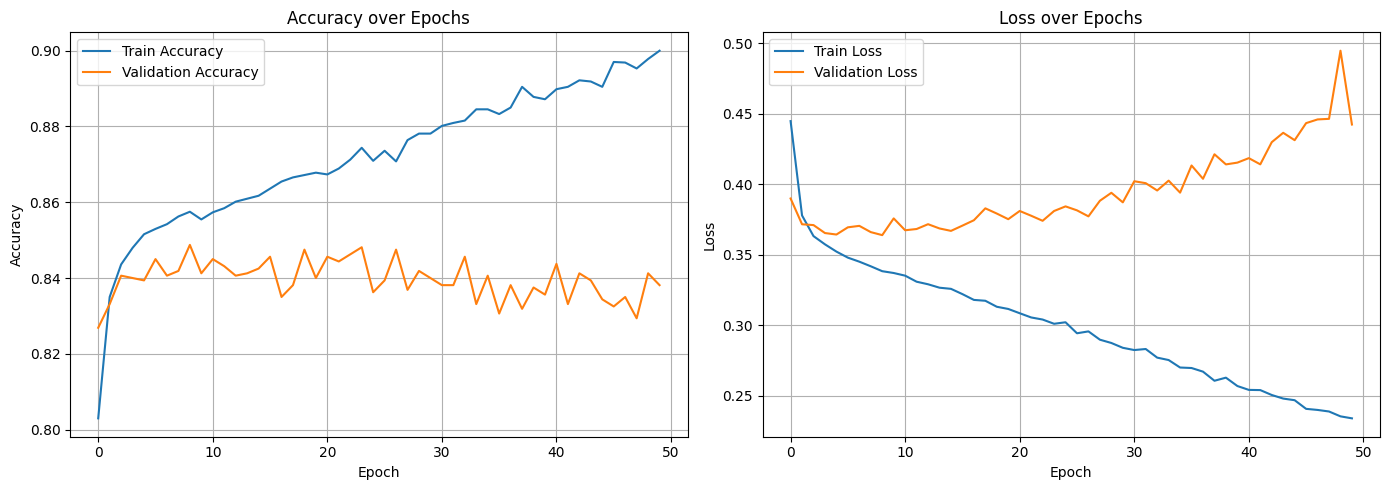

In [ ]:


# ----------- 1. نمودار دقت (Accuracy) و خطا (Loss) -----------

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


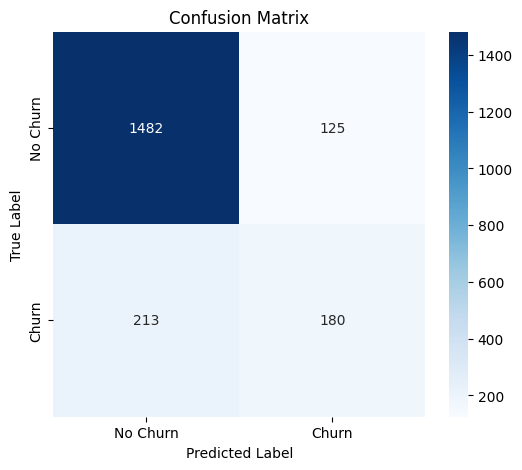

In [4]:

# ----------- 2. Confusion Matrix -----------

# تبدیل مقادیر پیش‌بینی‌شده به ۰ و ۱
predictions = model.predict(X_test)
pred_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(y_test, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


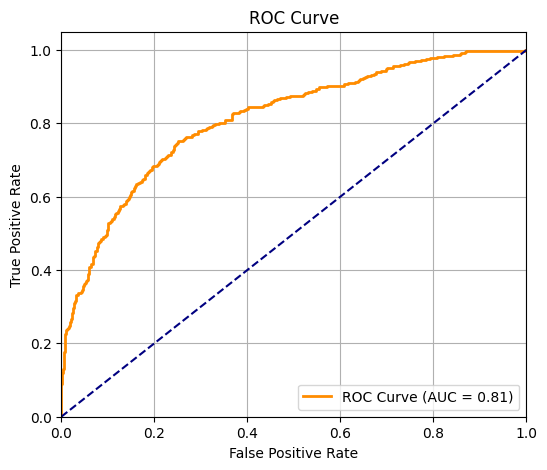

In [5]:

# ----------- 3. ROC Curve and AUC -----------

fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # خط مرجع
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## FNN

In [ ]:
# اعمال پیش‌پردازش
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# ساخت مدل مطابق مقاله (MLP با سه لایه مخفی و ReLU + خروجی Sigmoid)

# FNN - Feedforward Neural Network

model = keras.Sequential([
      layers.Input(shape=(X_train.shape[1],)),
      layers.Dense(64, activation='relu'),
      layers.Dense(32, activation='relu'),
      layers.Dense(1, activation='sigmoid')
    ])


# کامپایل مدل
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# آموزش مدل
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

# ارزیابی مدل
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')

# پیش‌بینی
predictions = model.predict(X_test)
predictions = (predictions > 0.5).astype(int)
print(f"Predictions:\n{predictions.ravel()}")



Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7041 - loss: 0.5512 - val_accuracy: 0.8138 - val_loss: 0.4287
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8117 - loss: 0.4164 - val_accuracy: 0.8313 - val_loss: 0.3871
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8320 - loss: 0.3807 - val_accuracy: 0.8331 - val_loss: 0.3744
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8406 - loss: 0.3760 - val_accuracy: 0.8444 - val_loss: 0.3687
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8443 - loss: 0.3658 - val_accuracy: 0.8369 - val_loss: 0.3715
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8487 - loss: 0.3595 - val_accuracy: 0.8450 - val_loss: 0.3661
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8503 - loss: 0.3548 - val_accuracy: 0.8413 - val_loss: 0.3664
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8517 - loss: 0.3541 - val_accuracy: 0.

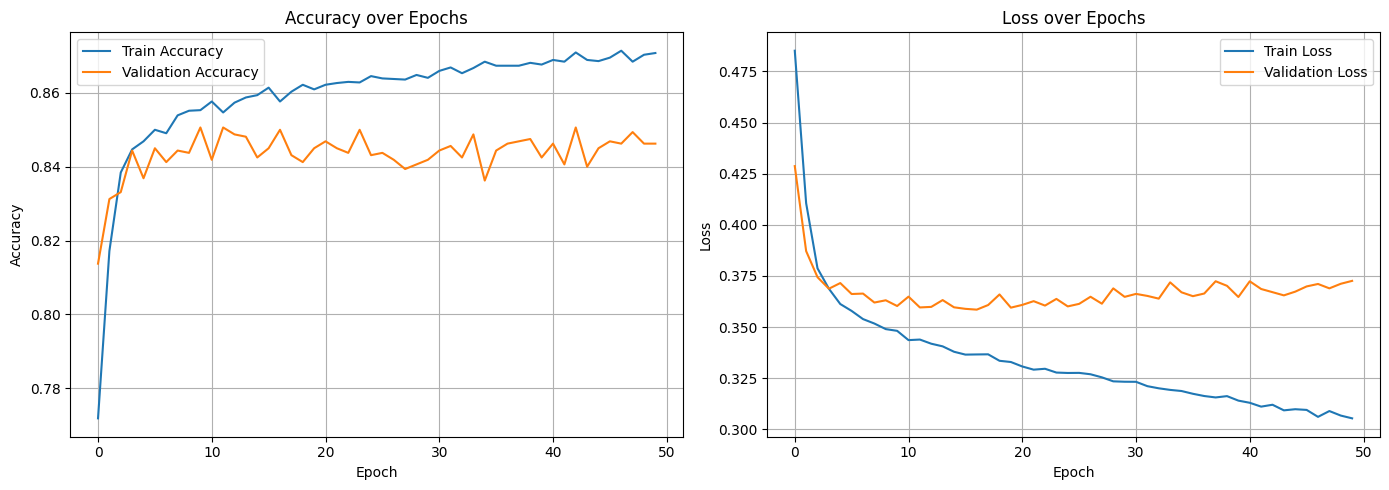

In [ ]:
# ----------- 1. نمودار دقت (Accuracy) و خطا (Loss) -----------

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


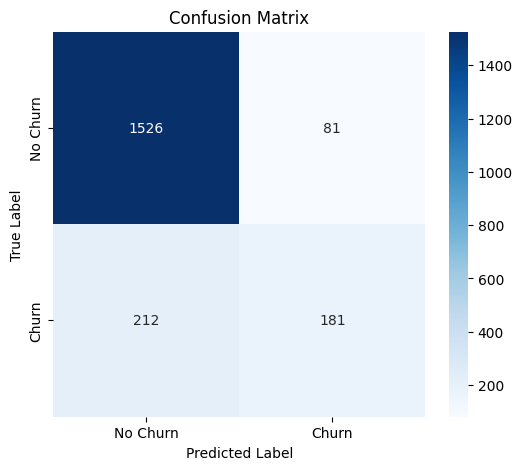

In [9]:

# ----------- 2. Confusion Matrix -----------

# تبدیل مقادیر پیش‌بینی‌شده به ۰ و ۱
predictions = model.predict(X_test)
pred_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(y_test, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


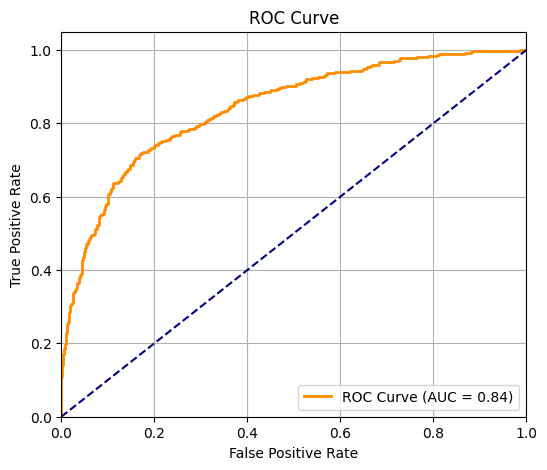

In [10]:

# ----------- 3. ROC Curve and AUC -----------

fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # خط مرجع
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## LSTM

In [ ]:
# تقسیم داده‌ها
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# اعمال پیش‌پردازش
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# تبدیل به شکل 3D برای LSTM: (samples, timesteps=1, features)
X_train_lstm = X_train_processed.reshape((X_train_processed.shape[0], 1, X_train_processed.shape[1]))
X_test_lstm = X_test_processed.reshape((X_test_processed.shape[0], 1, X_test_processed.shape[1]))

# ساخت مدل LSTM
model = keras.Sequential([
    layers.LSTM(50, input_shape=(1, X_train_processed.shape[1])),
    layers.Dense(1, activation='sigmoid')
])

# کامپایل
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# آموزش مدل
history = model.fit(X_train_lstm, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

# ارزیابی
loss, accuracy = model.evaluate(X_test_lstm, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')

# پیش‌بینی
predictions = model.predict(X_test_lstm)
predictions = (predictions > 0.5).astype(int)
print(f"Predictions:\n{predictions.ravel()}")


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7174 - loss: 0.6077 - val_accuracy: 0.8000 - val_loss: 0.4455
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7921 - loss: 0.4461 - val_accuracy: 0.8175 - val_loss: 0.4192
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7992 - loss: 0.4315 - val_accuracy: 0.8313 - val_loss: 0.3977
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8316 - loss: 0.3818 - val_accuracy: 0.8425 - val_loss: 0.3803
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8495 - loss: 0.3768 - val_accuracy: 0.8462 - val_loss: 0.3716
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8535 - loss: 0.3658 - val_accuracy: 0.8450 - val_loss: 0.3677
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8514 - loss: 0.3637 - val_accuracy: 0.8450 - val_loss: 0.3665
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8535 - loss: 0.3547 - val_accuracy: 0.8444 - val_

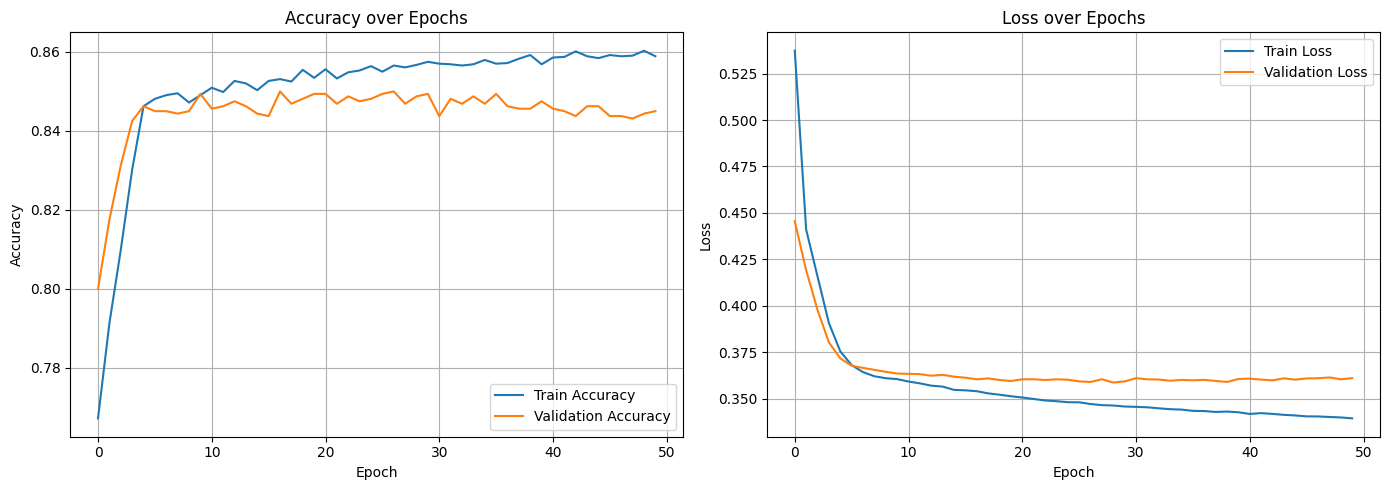

In [ ]:
# ----------- 1. نمودار دقت (Accuracy) و خطا (Loss) -----------

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


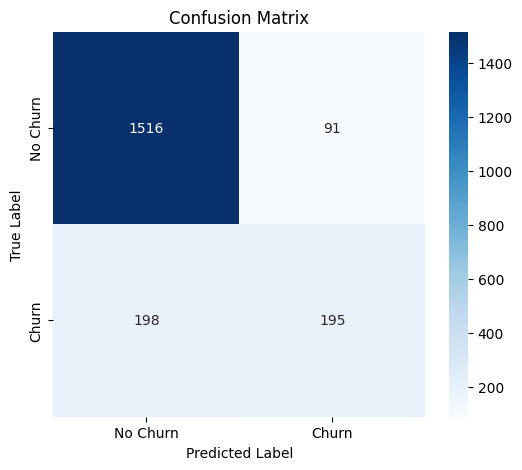

In [ ]:
# پیش‌بینی با داده‌ی صحیح
predictions = model.predict(X_test_lstm)
pred_labels = (predictions > 0.5).astype(int)

# محاسبه ماتریس درهم‌ریختگی
cm = confusion_matrix(y_test, pred_labels)

# رسم نمودار
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


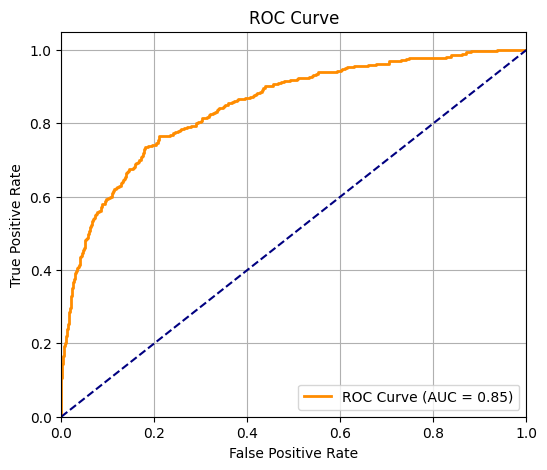

In [24]:

# ----------- 3. ROC Curve and AUC -----------

fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # خط مرجع
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# CNN - Conv1D

In [ ]:
# تقسیم داده‌ها
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# اعمال پیش‌پردازش
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# تبدیل داده‌های 2D به 3D برای CNN
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ساخت مدل CNN
model = keras.Sequential([
    layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# کامپایل مدل
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# آموزش مدل
history = model.fit(X_train_cnn, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

# ارزیابی مدل
loss, accuracy = model.evaluate(X_test_cnn, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')

# پیش‌بینی
predictions = model.predict(X_test_cnn)
predictions = (predictions > 0.5).astype(int)
print(f"Predictions:\n{predictions.ravel()}")


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7816 - loss: 0.5229 - val_accuracy: 0.8131 - val_loss: 0.4350
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8146 - loss: 0.4219 - val_accuracy: 0.8213 - val_loss: 0.4024
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8290 - loss: 0.3835 - val_accuracy: 0.8413 - val_loss: 0.3778
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8481 - loss: 0.3658 - val_accuracy: 0.8481 - val_loss: 0.3686
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8441 - loss: 0.3690 - val_accuracy: 0.8438 - val_loss: 0.3729
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8415 - loss: 0.3802 - val_accuracy: 0.8444 - val_loss: 0.3685
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8484 - loss: 0.3659 - val_accuracy: 0.8438 - val_loss: 0.3665
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8558 - loss: 0.3550 - val_accuracy: 0.8450 - val_

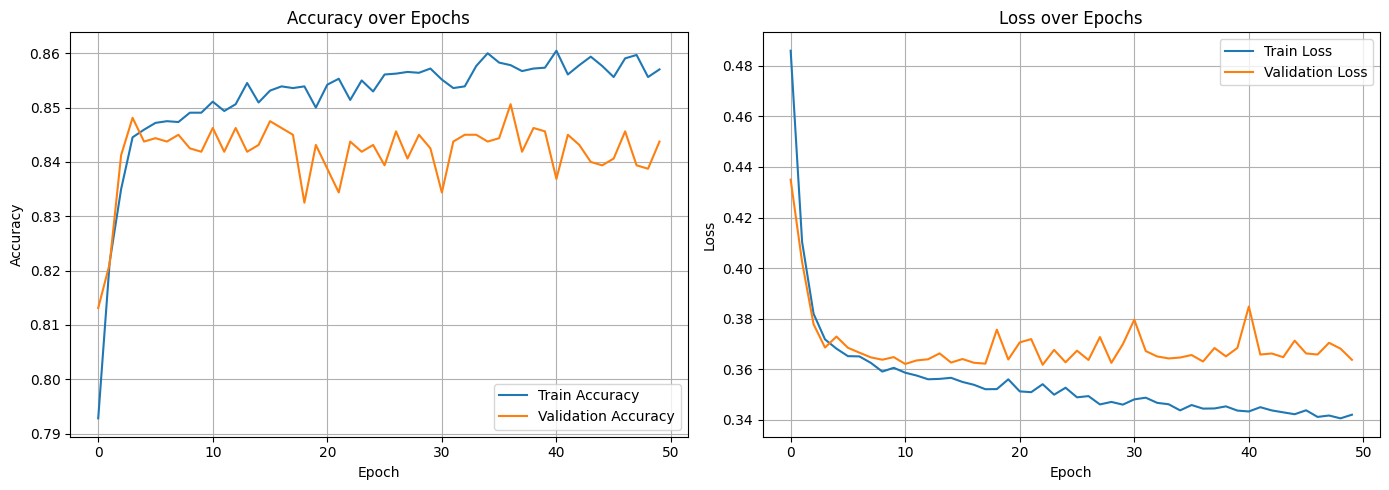

In [ ]:

# ----------- 1. نمودار دقت (Accuracy) و خطا (Loss) -----------

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



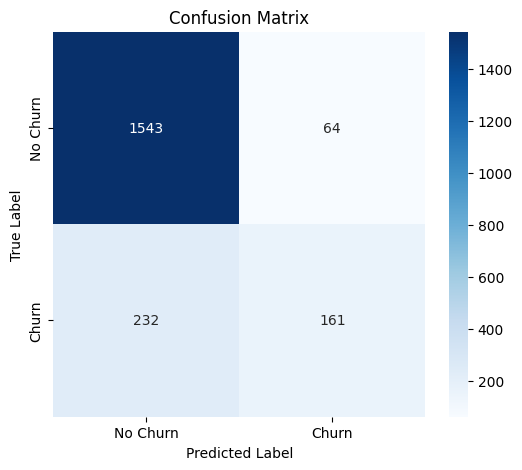

In [37]:
cm = confusion_matrix(y_test, predictions)

# رسم ماتریس
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



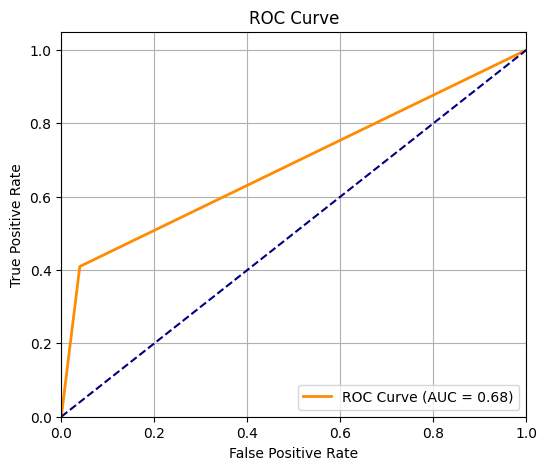

In [39]:

# ----------- 3. ROC Curve and AUC -----------

fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # خط مرجع
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()